In [4]:
%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
assert os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] == "false"

import sys
sys.path.append('../')
sys.path.append('../../')

import numpy as np
from matplotlib import pyplot as plt

import pint, logging
pint.logging.setup(level="WARNING")
logging.getLogger('enterprise').setLevel(logging.WARNING)

from pint.fitter import Fitter
from pint.models import get_model, get_model_and_toas
from pint.residuals import Residuals
from pint.simulation import make_fake_toas_uniform

from astropy import units as u
from copy import deepcopy
from tqdm import tqdm

from glob import glob
import enterprise

from jug.engine.session import TimingSession


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
model

TimingModel(
  AbsPhase(
    MJDParameter(   TZRMJD              53000.0000000007421512 (d) frozen=True),
    strParameter(   TZRSITE             ssb               frozen=True),
    floatParameter( TZRFRQ              inf               (MHz) frozen=True)),
  AstrometryEquatorial(
    MJDParameter(   POSEPOCH            53000.0000000000000000 (d) frozen=True),
    floatParameter( PX                  4.022912433261344 (mas) +/- 0.020657048423943628 mas frozen=False),
    floatParameter( VLBIAX              UNSET,
    floatParameter( VLBIAY              UNSET,
    floatParameter( VLBIAZ              UNSET,
    AngleParameter( RAJ                 0:30:27.42996300  (hourangle) +/- 0h00m00s frozen=False),
    AngleParameter( DECJ                4:51:39.75230000  (deg) +/- 0d00m00s frozen=False),
    floatParameter( PMRA                -4.05413525836408 (mas / yr) +/- 0.0600653766421753 mas / yr frozen=False),
    floatParameter( PMDEC               -5.033768650018044 (mas / yr) +/- 0.1400251

In [7]:
fit.model

TimingModel(
  AbsPhase(
    MJDParameter(   TZRMJD              53000.0000000007421512 (d) frozen=True),
    strParameter(   TZRSITE             ssb               frozen=True),
    floatParameter( TZRFRQ              inf               (MHz) frozen=True)),
  AstrometryEquatorial(
    MJDParameter(   POSEPOCH            53000.0000000000000000 (d) frozen=True),
    floatParameter( PX                  -17.395343024561157 (mas) +/- 0.02065703211316258 mas frozen=False),
    floatParameter( VLBIAX              UNSET,
    floatParameter( VLBIAY              UNSET,
    floatParameter( VLBIAZ              UNSET,
    AngleParameter( RAJ                 0:30:27.25865394  (hourangle) +/- 0h00m00.00001144s frozen=False),
    AngleParameter( DECJ                4:51:44.33133466  (deg) +/- 0d00m00.00039767s frozen=False),
    floatParameter( PMRA                1208.5402801589894 (mas / yr) +/- 0.05999414601979521 mas / yr frozen=False),
    floatParameter( PMDEC               -2410.382962646778 (ma

  0%|          | 0/36 [00:00<?, ?it/s]WARNING  (pint.models.timing_model      ): PINT does not support 'UNITS TCB' internally. Reading this par file nevertheless because the `allow_tcb` option was given. This `TimingModel` object should not be used for anything except converting to TDB.
WARNING  (pint.logging                  ): /home/kyleg/miniforge3/envs/atlas/lib/python3.12/site-packages/pint/models/model_builder.py:220 UserWarning: Unrecognized parfile line 'EPHVER 5'
WARNING  (pint.models.tcb_conversion    ): Converting this timing model from TCB to TDB. Please note that the TCB to TDB conversion is only approximate and the resulting timing model should be re-fit to get reliable results.
WARNING  (pint.models.absolute_phase    ): TZRMJD is not set.  Setting TZRMJD to first TOA after PEPOCH or last TOA before PEPOCH.  This may leave your residuals with an offset.


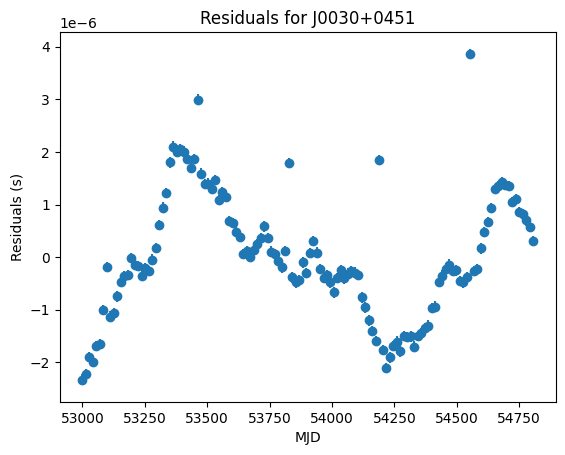

  0%|          | 0/36 [00:01<?, ?it/s]


In [21]:
inpath = '../../../../datasets/MDC1_t2/'
outpath = '../../../../datasets/MDC1_pint/'

parfiles = sorted(glob(inpath + 'par/*.par'))
timfiles = sorted(glob(inpath + 'tim/*.tim'))
npsrs = len(parfiles)

for i in tqdm(range(npsrs)):
    par, tim = parfiles[i], timfiles[i]
    model, toas = get_model_and_toas(par, tim, allow_T2=True, allow_tcb=True)

    fit = pint.fitter.Fitter.auto(toas, model)
    fit.fit_toas(maxiter=100)
    name = model.PSR.value

    res = Residuals(fit.toas, fit.model)
    t = fit.toas.get_mjds().value
    r = res.time_resids.to(u.s).value
    s = fit.toas.get_errors().to(u.s).value
    plt.errorbar(t, r, yerr=s, fmt='o')
    plt.xlabel('MJD')
    plt.ylabel('Residuals (s)')
    plt.title(f'Residuals for {name}')
    plt.show()

    fit.model.write_parfile(f'{outpath}/par/{name}.par')
    fit.toas.write_TOA_file(f'{outpath}/tim/{name}.tim')

    break


In [12]:
import pickle
with open('/home/kyleg/projects/datasets/MDC1_t2/mdc1_psrs.pkl', 'rb') as f:
    mdc1_psrs = pickle.load(f)

libstempo not installed. PINT or libstempo are required to use par and tim files.


<ErrorbarContainer object of 3 artists>

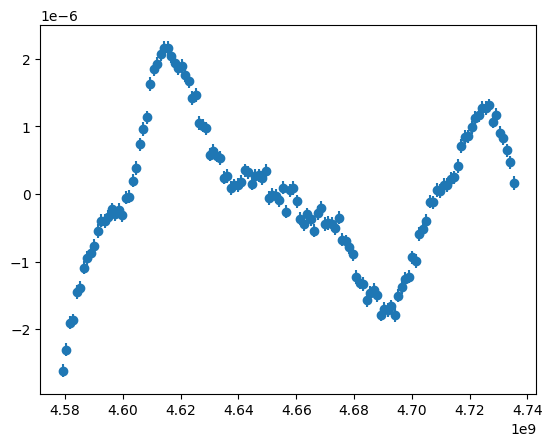

In [14]:
p = mdc1_psrs[0]
t = p.toas
r = p.residuals
s = p.toaerrs
plt.errorbar(t, r, yerr=s, fmt='o')

<ErrorbarContainer object of 3 artists>

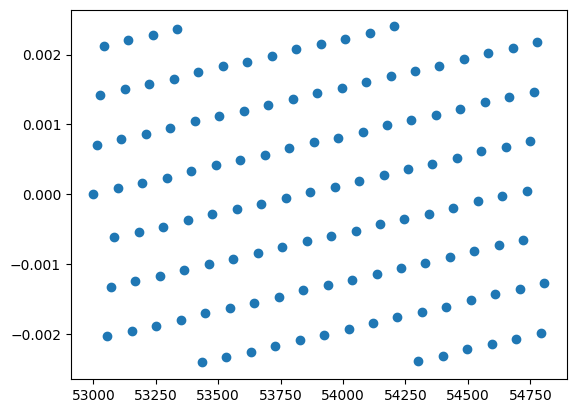

In [3]:
res = Residuals(toas, model)
t = toas.get_mjds().value
r = res.time_resids.to(u.s).value
s = toas.get_errors().to(u.s).value

plt.errorbar(t, r, yerr=s, fmt='o')

In [3]:
from enterprise.pulsar import Pulsar
parfiles = sorted(glob(outpath + 'par/*.par'))
timfiles = sorted(glob(outpath + 'tim/*.tim'))

psrs = [Pulsar(parfiles[i],timfiles[i]) for i in tqdm(range(npsrs))]

import pickle
with open(f'{outpath}/psrs.pkl', 'wb') as f:
    pickle.dump(psrs, f)

libstempo not installed. PINT or libstempo are required to use par and tim files.
100%|██████████| 36/36 [02:41<00:00,  4.48s/it]


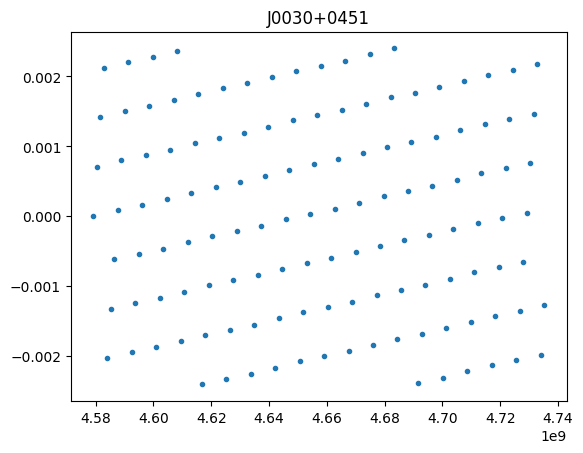

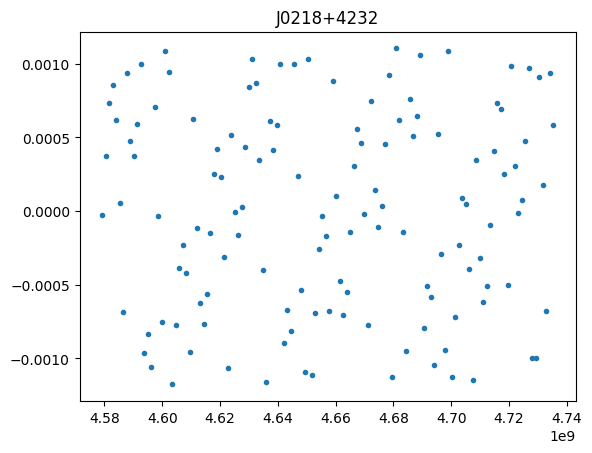

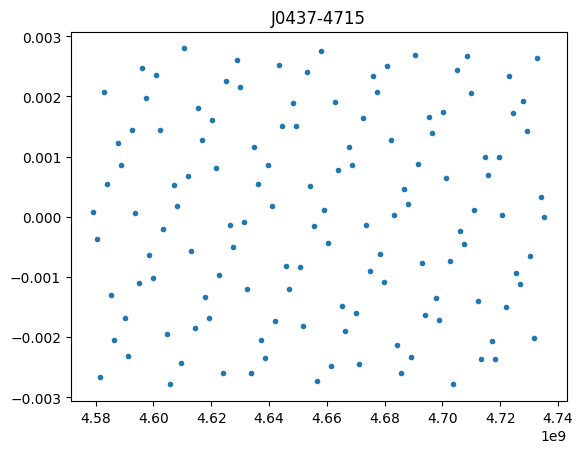

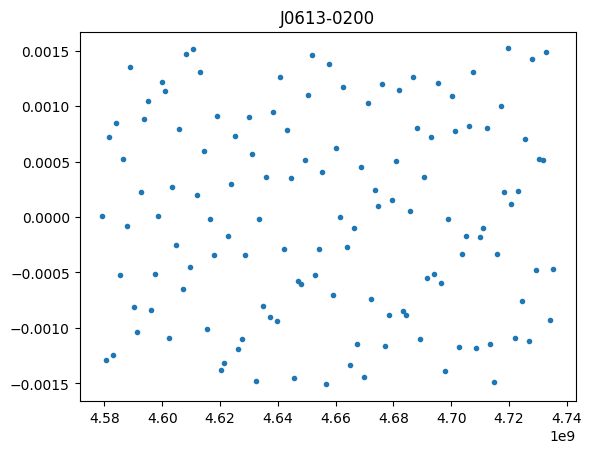

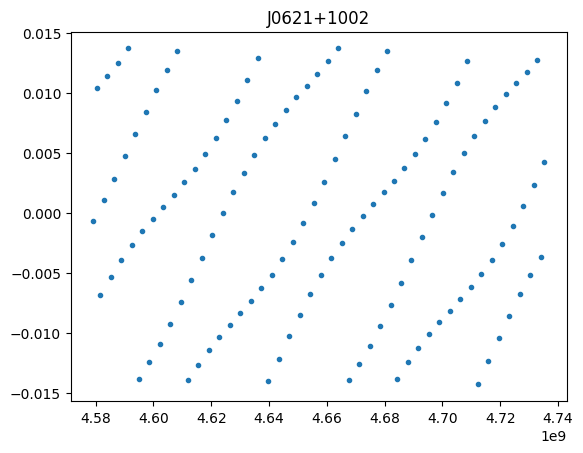

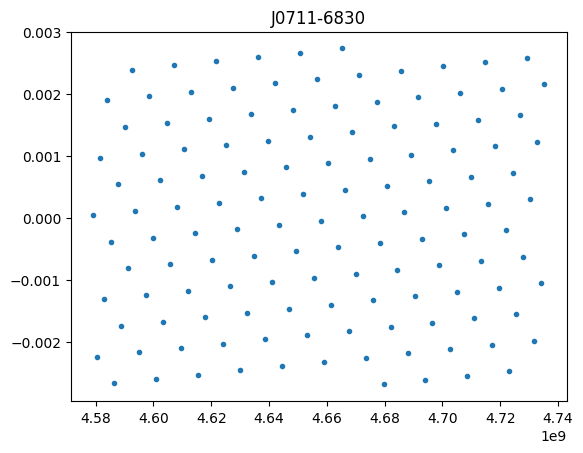

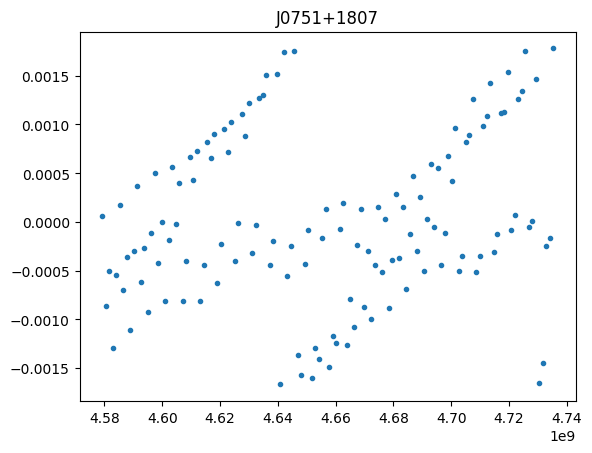

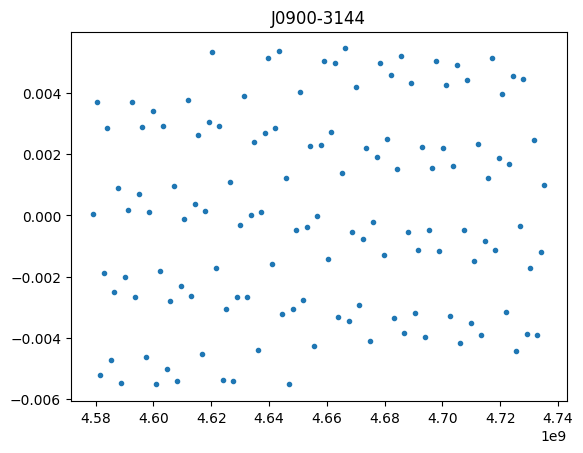

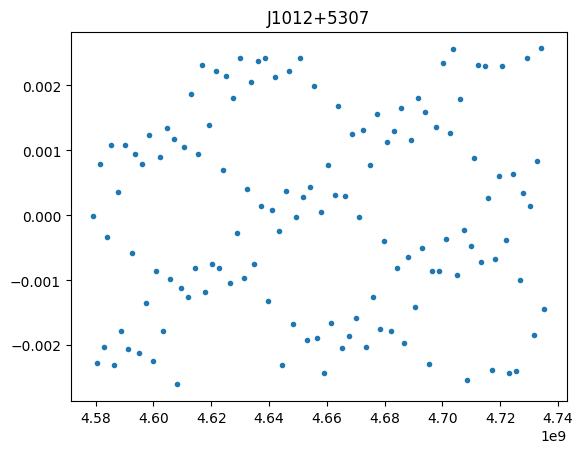

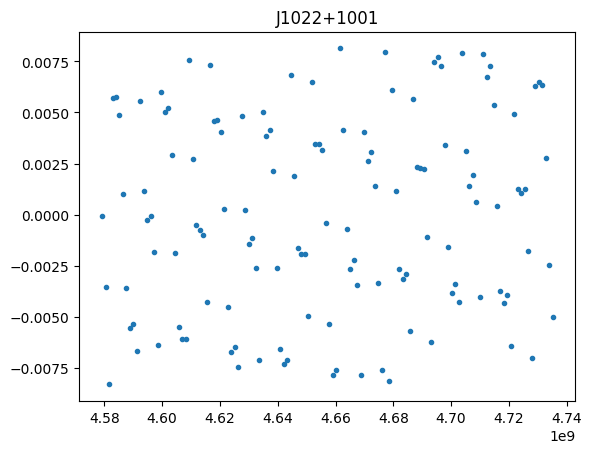

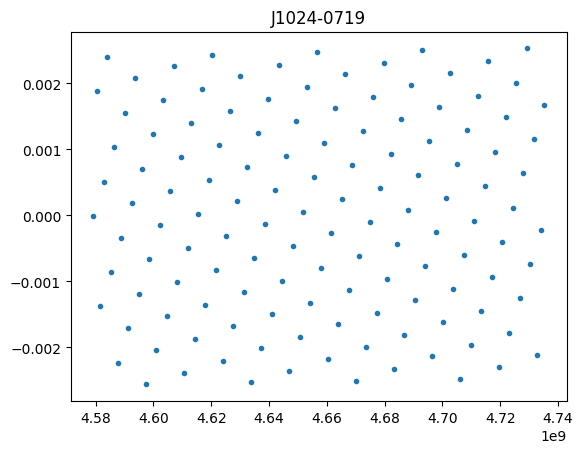

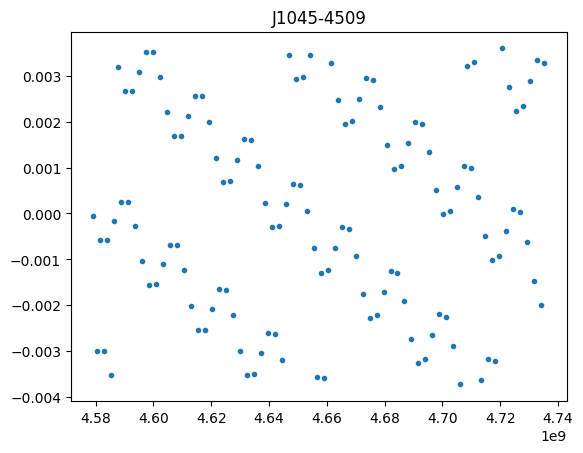

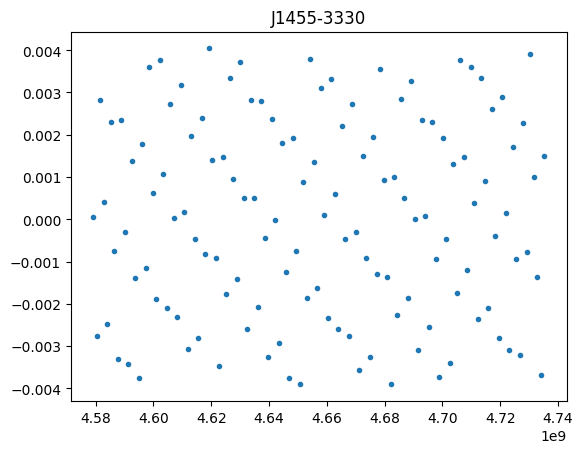

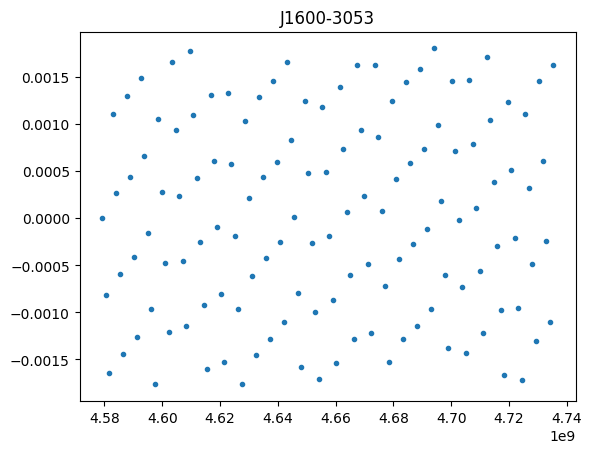

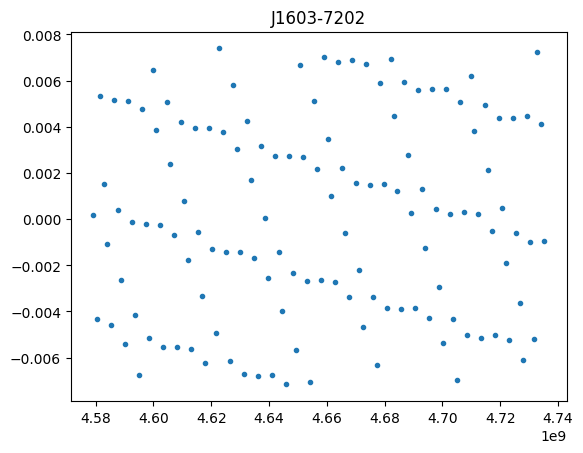

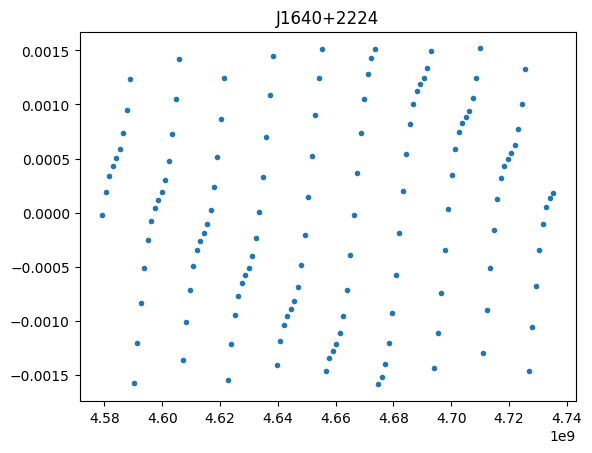

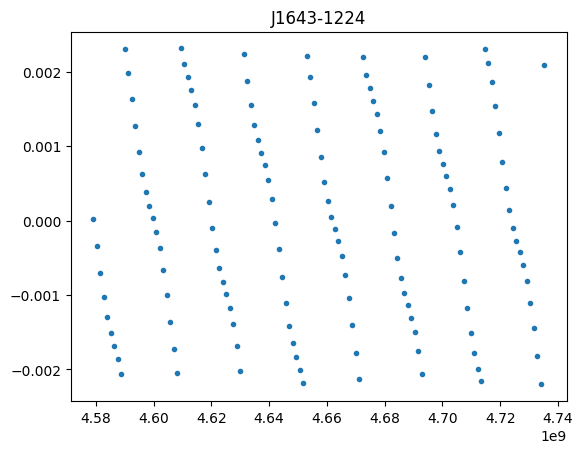

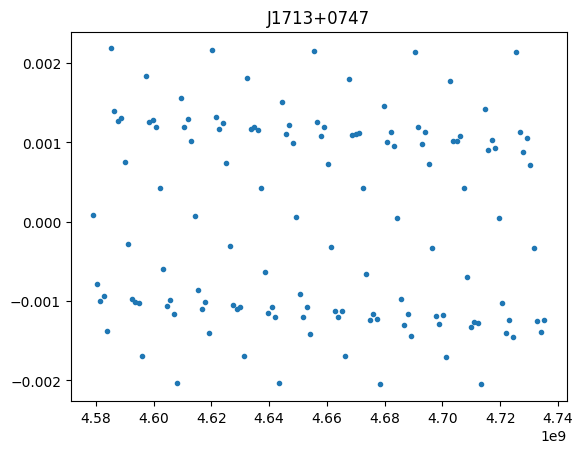

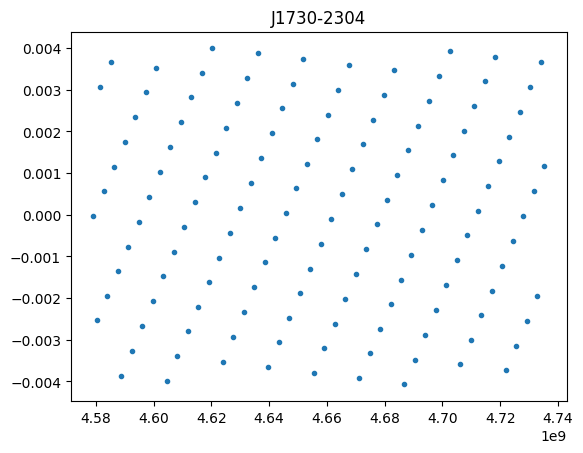

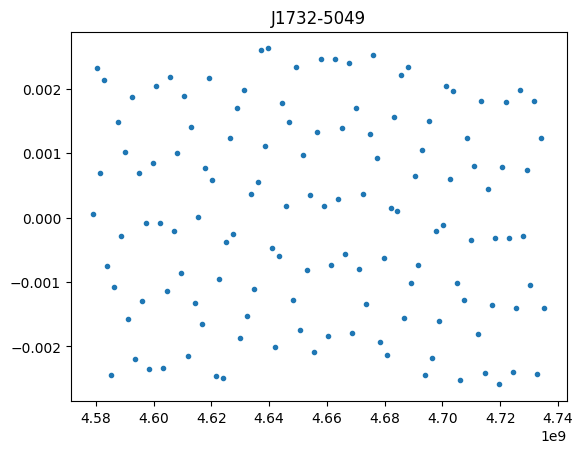

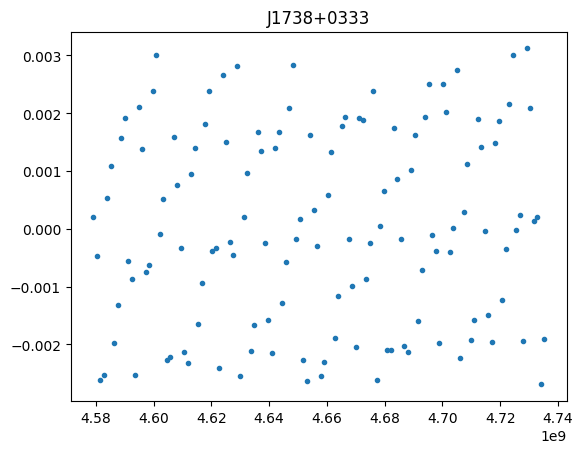

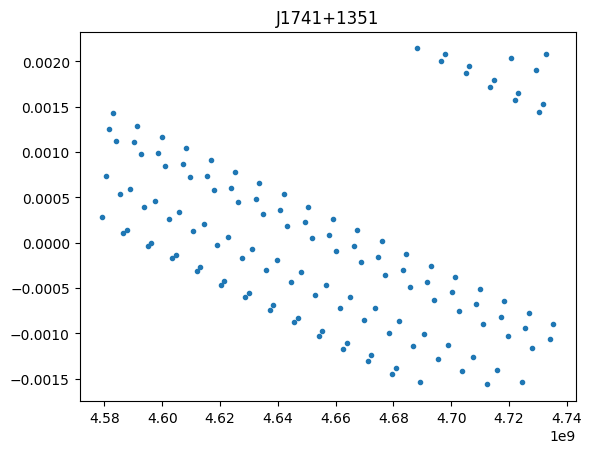

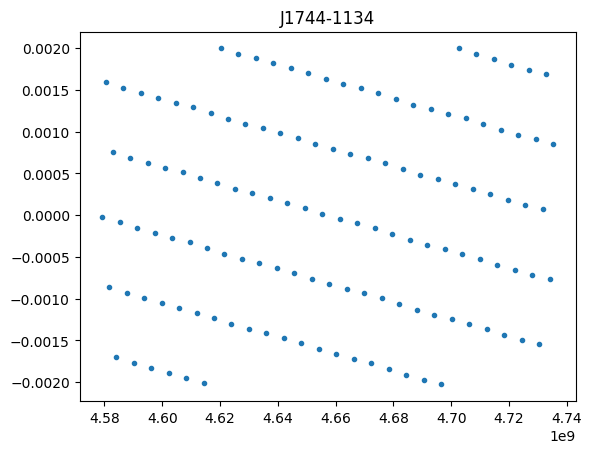

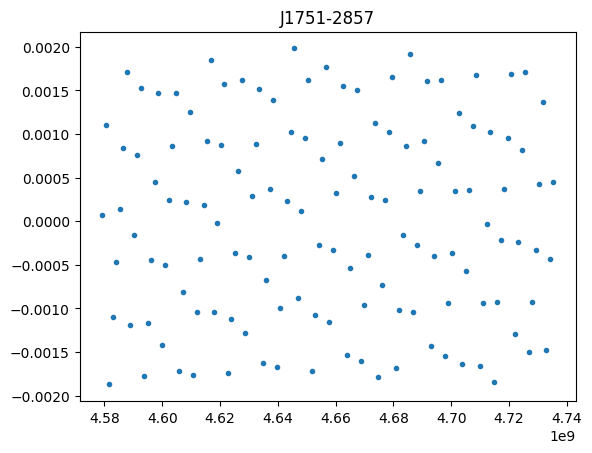

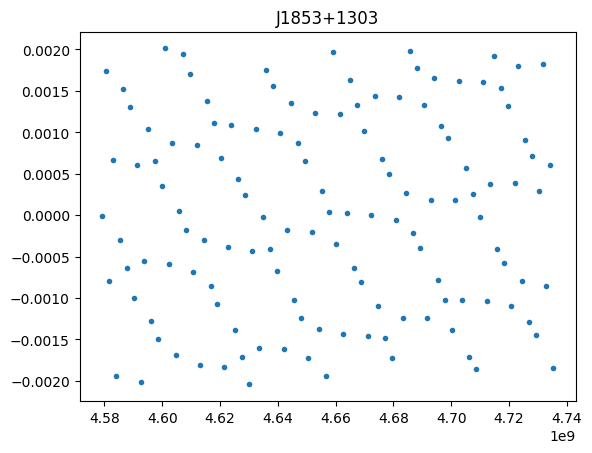

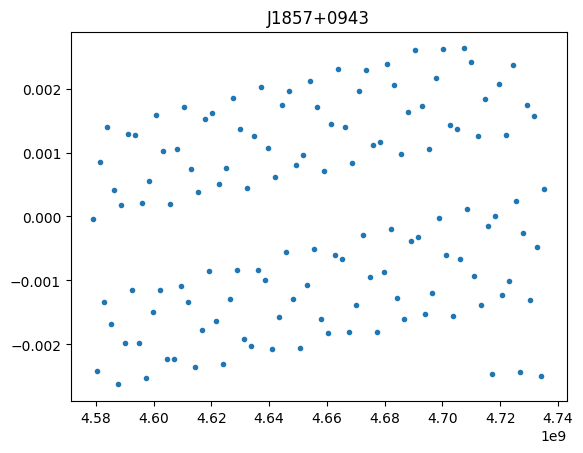

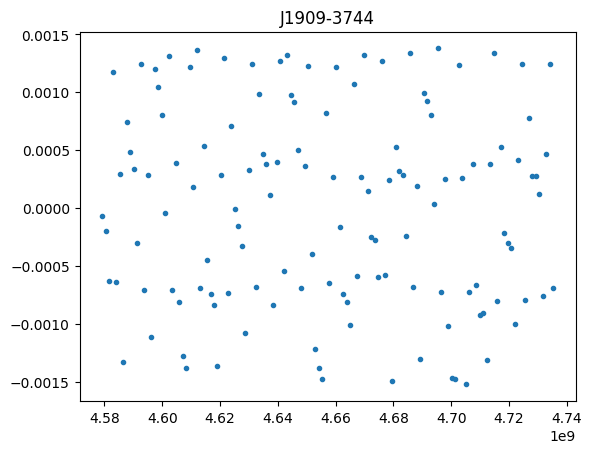

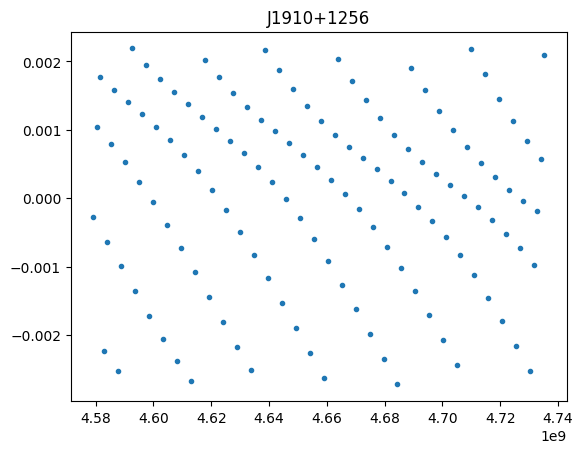

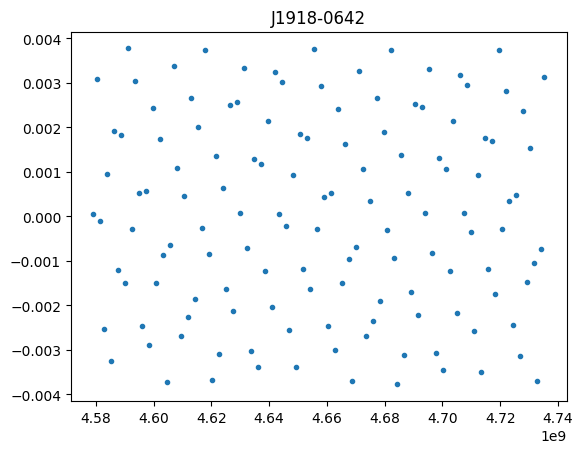

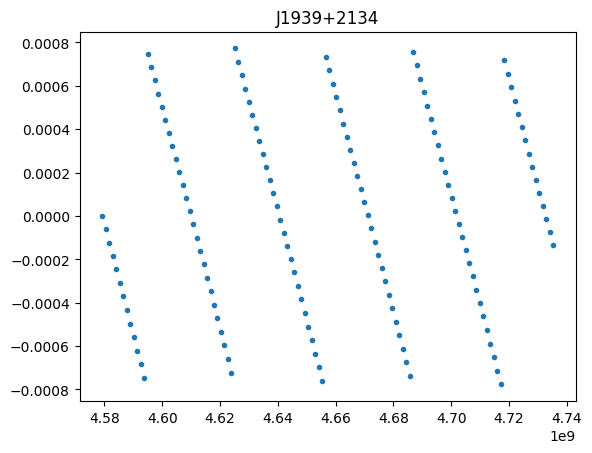

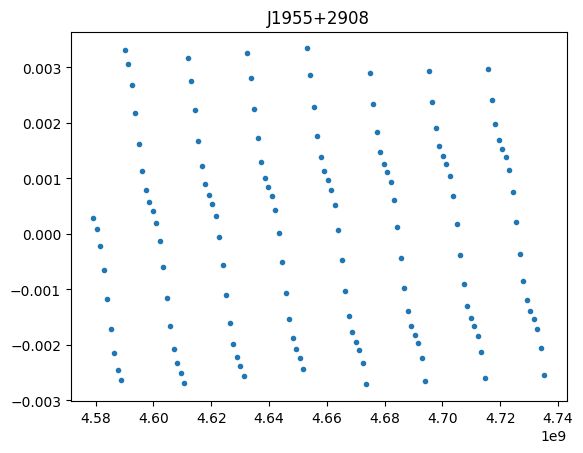

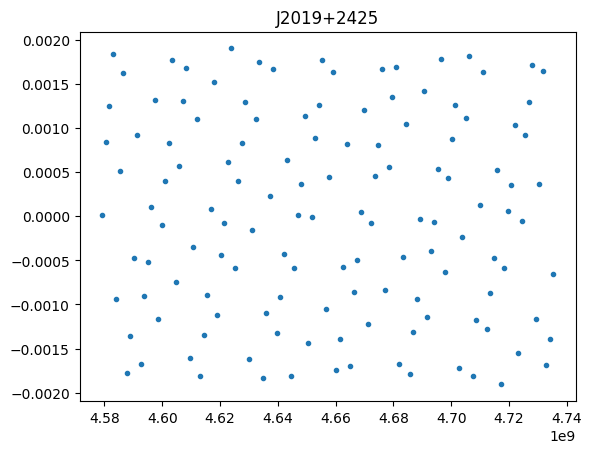

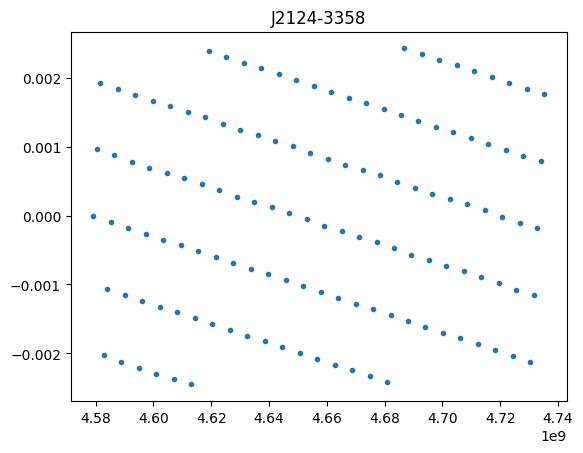

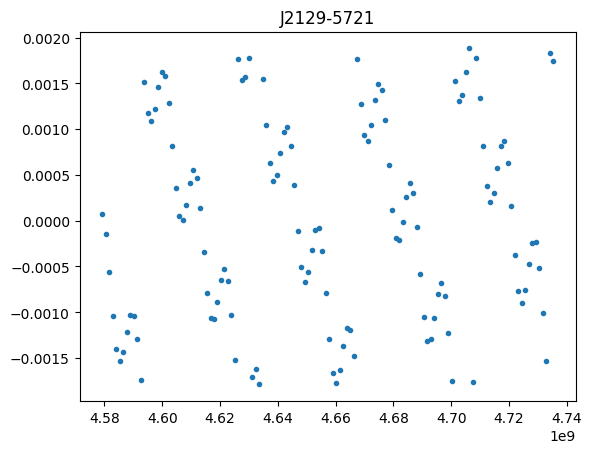

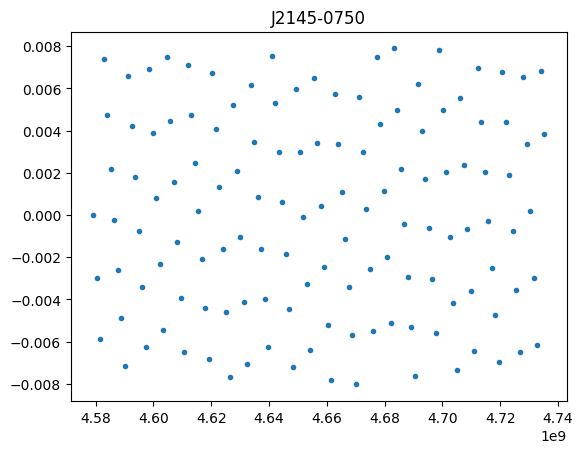

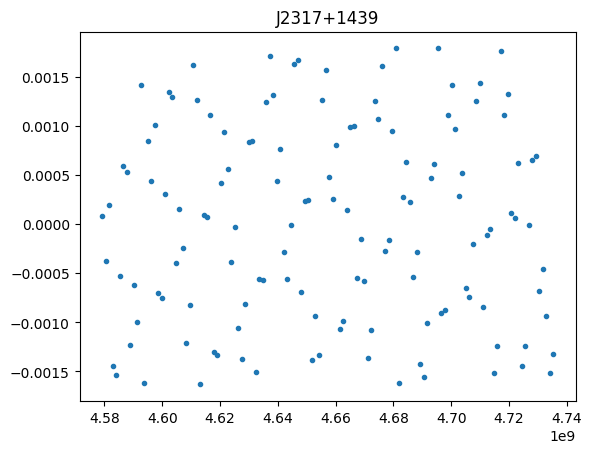

In [40]:
for p in psrs:
    plt.errorbar(p.toas, p.residuals, p.toaerrs, fmt='.')
    plt.title(f'{p.name}')
    plt.show()

In [38]:
# Lets make sure that it works properly still
from enterprise_extensions.model_utils import get_tspan
from enterprise.signals import parameter, white_signals, gp_signals, signal_base
from enterprise_extensions import blocks, sampler



Tspan = get_tspan(psrs)

efac = parameter.Constant(1.0)
ef = white_signals.MeasurementNoise(efac=efac)
gwb = blocks.common_red_noise_block(psd='powerlaw', Tspan=Tspan, components=10, orf='crn',
                                    gamma_val=None, logmin=-18, logmax=-12, name='gw')
#irn = blocks.red_noise_block(psd='powerlaw',Tspan=Tspan,components=30)
tm = gp_signals.MarginalizingTimingModel()
model = tm + ef + gwb
pta = signal_base.PTA([model(psr) for psr in psrs])

sam = sampler.setup_sampler(pta, 'test', resume=False)
x0 = np.hstack([p.sample() for p in pta.params])
sam.sample(x0, 10000, AMweight=1000)


Adding GWB uniform distribution draws...

Finished 0.00 percent in 0.001614 s Acceptance rate = 0

WARNING  (pint.logging                  ): /home/kyleg/miniforge3/envs/atlas/lib/python3.12/site-packages/enterprise/signals/parameter.py:70 RuntimeWarning: divide by zero encountered in log


TypeError: only 0-dimensional arrays can be converted to Python scalars

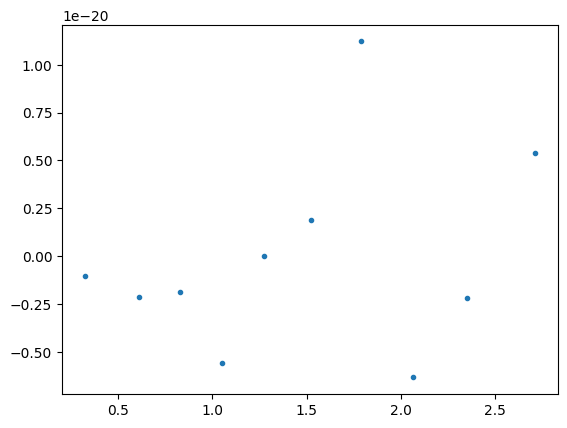

-3.0208372233000998e-21 1.9089578042587215e-28 -15824536.386089155


In [33]:
from defiant import OptimalStatistic
from defiant import utils

os_obj = OptimalStatistic(psrs, pta)
out = os_obj.compute_OS(params={'gw_log10_A': np.log10(5e-14)})
xi, rho, sig, A2, A2s = out['xi'], out['rho'], out['sig'], out['A2'], out['A2s']

xia,rhoa,siga = utils.binned_pair_correlations(xi, rho, sig)
plt.errorbar(xia, rhoa, yerr=siga, fmt='.')
plt.show()

print(A2, A2s, A2/A2s)